# RR-CTP Semiglobal Checkpoint Walkthrough

This notebook loads the trained RR-CTP checkpoint from
`experiments/IN718/iso_embedding_rrctp_semiglobal_01`, then walks through the
pipeline in the same order as the model:

1. encode one LR quaternion map into local-isometry features
2. trace the RRCTP upsampler step by step
3. decode selected intermediate features back to quaternions

The notebook is organized around two concrete questions:

- For a chosen HR pixel, how does the model use semiglobal LR evidence beyond the
  mapped parent LR pixel?
- At each RRCTP substep, how much of the feature energy lives in the FCC `a1`
  subspace, and what is decoder-viable if we push that stage through a quaternion
  decoder?

This notebook is written for the **FCC / IN718 / isotropic x4** RRCTP experiment.
Open it in the same environment used to train the model, i.e. one that can import
`torch`, `e3nn`, `orix`, and the repo modules.


In [25]:
from __future__ import annotations

import inspect
import json
import math
import os
import sys
from pathlib import Path

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from e3nn.o3 import Irreps
from IPython.display import display, Markdown
from matplotlib.patches import Rectangle


def find_repo_root(start: Path | None = None) -> Path:
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for path in [start, *start.parents]:
        if (path / "models").exists() and (path / "experiments").exists():
            return path
    raise RuntimeError("Could not locate repo root from current working directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.SR_rrctp_semiglobal import (
    IsoEmbeddingSRRRCTP,
    CubochoricOptimizingLocalIsoDecoder,
    _normalize_quaternions,
)
from training.quaternion_dataset import QuaternionDataset
from utils.stage_probe_utils import quat_ang_err_deg
from utils.symmetry_utils import resolve_symmetry
from visualization.ipf_render import render_ipf_rgb

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.dpi"] = 120
torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)


In [26]:
EXP_DIR = ROOT / "experiments" / "IN718" / "iso_embedding_rrctp_semiglobal_01"
CONFIG_PATH = EXP_DIR / "logs" / "run_config.json"
CHECKPOINT_PATH = EXP_DIR / "checkpoints" / "best_model.pt"
DATA_SPLIT = "Val"
SAMPLE_INDEX = 0
REF_DIR = "X"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MANUAL_PROBE_YX = (50, 82)  # (y, x) from the provided SR IPF-X image: white seam on the left edge of the purple grain
NUM_PROBE_PIXELS = 4
AUTO_PROBE_MODE = "boundary_color_anomaly"  # or "largest_non_parent_mass" / "largest_shift"
TOP_CANDIDATES_TO_SHOW = 10
FIG_DIR = ROOT / "ideas" / "out" / "rrctp_checkpoint_walkthrough"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = json.load(open(CONFIG_PATH, "r"))
print("Repo root:", ROOT)
print("Experiment:", EXP_DIR)
print("Checkpoint exists:", CHECKPOINT_PATH.exists(), CHECKPOINT_PATH)
print("Device:", DEVICE)
print("Configured feature_irreps:", cfg.get("feature_irreps"))
print("Configured upsample_factor:", cfg.get("upsample_factor"))


Repo root: /data/home/umang/Materials/Reynolds-QSR_4x1
Experiment: /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_rrctp_semiglobal_01
Checkpoint exists: True /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_rrctp_semiglobal_01/checkpoints/best_model.pt
Device: cuda
Configured feature_irreps: full
Configured upsample_factor: 4


## Helper Functions

The next cell keeps all of the notebook mechanics in one place:

- loading the trained checkpoint
- preparing one dataset sample
- tracing the RRCTP substeps manually
- extracting the FCC `a1` slice from the trained `full = 2e ⊕ 4e` feature space
- decoding selected intermediate features with both the full decoder and an `a1`
  decoder built from the same encoder


In [27]:
def to_hwc_quat(q: torch.Tensor) -> torch.Tensor:
    q = torch.as_tensor(q, dtype=torch.float32)
    if q.dim() != 3:
        raise ValueError(f"Expected rank-3 quaternion image, got {tuple(q.shape)}")
    if q.shape[0] == 4:
        return q.permute(1, 2, 0).contiguous()
    if q.shape[-1] == 4:
        return q.contiguous()
    raise ValueError(f"Could not find quaternion axis in shape {tuple(q.shape)}")


def flatten_quat_hwc(q_hwc: torch.Tensor) -> tuple[torch.Tensor, tuple[int, int]]:
    h, w = int(q_hwc.shape[0]), int(q_hwc.shape[1])
    return q_hwc.reshape(h * w, 4).contiguous(), (h, w)


def irrep_block_slices(irreps: Irreps | str):
    start = 0
    out = []
    for mul, ir in Irreps(irreps):
        width = int(mul) * int(ir.dim)
        out.append((start, start + width, int(mul), ir))
        start += width
    return out


def find_trailing_irrep_slice(full_irreps: Irreps | str, sub_irreps: Irreps | str) -> slice:
    full = list(Irreps(full_irreps))
    sub = list(Irreps(sub_irreps))
    full_sig = [(int(m), int(ir.l), int(ir.p)) for m, ir in full]
    sub_sig = [(int(m), int(ir.l), int(ir.p)) for m, ir in sub]
    if not full_sig[-len(sub_sig):] == sub_sig:
        raise ValueError(
            f"Expected sub_irreps to be a trailing block sequence of full_irreps, got "
            f"full={Irreps(full_irreps)} and sub={Irreps(sub_irreps)}"
        )
    start = 0
    for mul, ir in full[:-len(sub)]:
        start += int(mul) * int(ir.dim)
    end = start
    for mul, ir in sub:
        end += int(mul) * int(ir.dim)
    return slice(start, end)


def instantiate_model_from_config(cfg: dict, device: torch.device) -> IsoEmbeddingSRRRCTP:
    sig = inspect.signature(IsoEmbeddingSRRRCTP.__init__)
    kwargs = {}
    for name in sig.parameters:
        if name == "self":
            continue
        if name == "device":
            kwargs[name] = device
        elif name in cfg:
            kwargs[name] = cfg[name]
    model = IsoEmbeddingSRRRCTP(**kwargs).to(device)
    return model.eval()


def load_trained_rrctp(exp_dir: Path, device: torch.device):
    cfg = json.load(open(exp_dir / "logs" / "run_config.json", "r"))
    ckpt = torch.load(
        exp_dir / "checkpoints" / "best_model.pt",
        map_location=device,
        weights_only=False,
    )
    model = instantiate_model_from_config(cfg, device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    sym_class = resolve_symmetry(cfg.get("symmetry_group", "Oh"))

    decoder_full = model._ensure_decoder()
    decoder_a1 = CubochoricOptimizingLocalIsoDecoder(
        encoder=model.encoder,
        cubochoric_resolution=int(cfg.get("decoder_cubochoric_resolution", 1)),
        method=str(cfg.get("decoder_method", "cubochoric")),
        num_starts=int(cfg.get("decoder_num_starts", 2)),
        steps=int(cfg.get("decoder_steps", 0)),
        lr=float(cfg.get("decoder_lr", 0.05)),
        target_irreps="a1",
        max_table_rows=cfg.get("decoder_max_table_rows"),
        table_cache_dir=cfg.get("decoder_table_cache_dir", "out/decoder_lookup_tables"),
    )
    return cfg, ckpt, model, sym_class, decoder_full, decoder_a1


def load_dataset_sample(dataset_root: str, split: str, index: int):
    ds = QuaternionDataset(
        dataset_root=dataset_root,
        split=split,
        preload=False,
        preload_torch=False,
        pin_memory=False,
        return_lr_boundary_map=False,
    )
    lr, hr = ds[index]
    return to_hwc_quat(lr), to_hwc_quat(hr)


def decode_full_features(model: IsoEmbeddingSRRRCTP, feat_flat: torch.Tensor) -> torch.Tensor:
    feat_flat = feat_flat.to(device=model.device, dtype=torch.float32)
    with torch.enable_grad():
        q = model._ensure_decoder()(feat_flat)
    q = model.reduce_to_fz(q)
    return q.detach().cpu()


def decode_a1_features(
    model: IsoEmbeddingSRRRCTP,
    decoder_a1: CubochoricOptimizingLocalIsoDecoder,
    feat_a1_flat: torch.Tensor,
) -> torch.Tensor:
    feat_a1_flat = feat_a1_flat.to(device=model.device, dtype=torch.float32)
    with torch.enable_grad():
        q = decoder_a1(feat_a1_flat)
    q = model.reduce_to_fz(q)
    return q.detach().cpu()


def quat_rgb_swatch(q_wxyz: torch.Tensor, sym_class, ref_dir: str = "X") -> np.ndarray:
    q = q_wxyz.detach().cpu().view(1, 1, 4).numpy().astype(np.float32)
    rgb = render_ipf_rgb(q, sym_class, ref_dir=ref_dir)
    if isinstance(rgb, list):
        rgb = rgb[0]
    return np.asarray(rgb[0, 0], dtype=np.float32)


def pair_misorientation_deg(q_pred: torch.Tensor, q_tgt: torch.Tensor, sym_class) -> float:
    pred = q_pred.detach().cpu().view(1, 1, 4)
    tgt = q_tgt.detach().cpu().view(1, 1, 4)
    return float(quat_ang_err_deg(pred, tgt, sym=sym_class)[0, 0].item())


def trace_rrctp_substeps(
    model: IsoEmbeddingSRRRCTP,
    feat_lr_b1: torch.Tensor,
    lr_shape: tuple[int, int],
) -> dict:
    rrctp = model.rrctp
    h_lr, w_lr = int(lr_shape[0]), int(lr_shape[1])
    bsz, n_lr, c_dim = feat_lr_b1.shape
    if bsz != 1:
        raise ValueError("trace_rrctp_substeps expects batch size 1.")
    if n_lr != h_lr * w_lr:
        raise ValueError(f"Expected N={h_lr*w_lr}, got {n_lr}")

    with torch.no_grad():
        feat_lr_img = feat_lr_b1.view(1, h_lr, w_lr, c_dim).permute(0, 3, 1, 2).contiguous()
        parent_bank = rrctp._build_parent_patch_bank(feat_lr_img)
        parent_idx, phase_idx, rel_offsets = rrctp._get_index_tensors((h_lr, w_lr), feat_lr_b1.device)
        rel_offsets = rel_offsets.to(device=feat_lr_b1.device, dtype=feat_lr_b1.dtype)

        parent_feat = feat_lr_b1.index_select(1, parent_idx)
        cand = parent_bank.index_select(1, parent_idx)

        ph = rrctp.phase_embed(phase_idx).to(dtype=feat_lr_b1.dtype).unsqueeze(0)
        q0 = rrctp.query_anchor(parent_feat, ph)

        g, gate_terms = rrctp.window_gate(q0, cand, same_grain=None)
        cand_stats = rrctp.stat_builder.query_candidates(q0, cand)
        score = rrctp.candidate_scorer(cand_stats, rel_offsets=rel_offsets, phase_embed=ph)
        logits = score + torch.log(g.unsqueeze(2))
        alpha = torch.softmax(logits, dim=-1)

        ctx = torch.einsum("bukm,bumc->bukc", alpha, cand)
        g_norm = g / g.sum(dim=-1, keepdim=True).clamp_min(1e-6)
        bank_sum = torch.einsum("bum,bumc->buc", g_norm, cand)

        router_stats = rrctp.stat_builder.query_summary(q0, bank_sum)
        router_logits = rrctp.router(router_stats, ph)
        topk_val, topk_idx = torch.topk(router_logits, k=rrctp.top_k, dim=-1)
        topk_pi = torch.softmax(topk_val, dim=-1)

        ctx_stats = rrctp.stat_builder.query_contexts(q0, ctx)
        seed_all = rrctp.seed_heads(q0, ctx, ph, ctx_stats)
        idx_seed = topk_idx.unsqueeze(-1).expand(1, parent_idx.numel(), rrctp.top_k, c_dim)
        seed_sel = torch.gather(seed_all, dim=2, index=idx_seed)
        seed = (topk_pi.unsqueeze(-1) * seed_sel).sum(dim=2)

        u_hr = parent_idx.numel()
        top1_idx = topk_idx[..., :1]
        alpha_top1 = torch.gather(
            alpha,
            dim=2,
            index=top1_idx.unsqueeze(-1).expand(1, u_hr, 1, rrctp.window_size * rrctp.window_size),
        ).squeeze(2)
        ctx_top1 = torch.gather(
            ctx,
            dim=2,
            index=top1_idx.unsqueeze(-1).expand(1, u_hr, 1, c_dim),
        ).squeeze(2)
        seed_top1 = torch.gather(
            seed_all,
            dim=2,
            index=top1_idx.unsqueeze(-1).expand(1, u_hr, 1, c_dim),
        ).squeeze(2)

        ctx_sel = torch.gather(
            ctx,
            dim=2,
            index=topk_idx.unsqueeze(-1).expand(1, u_hr, rrctp.top_k, c_dim),
        )
        ctx_mix = (topk_pi.unsqueeze(-1) * ctx_sel).sum(dim=2)

        rad = rrctp.window_size // 2
        int_offsets = []
        for dy in range(-rad, rad + 1):
            for dx in range(-rad, rad + 1):
                int_offsets.append((dy, dx))
        int_offsets = torch.tensor(int_offsets, dtype=torch.float32, device=feat_lr_b1.device)

        parent_y = torch.div(parent_idx, w_lr, rounding_mode="floor")
        parent_x = torch.remainder(parent_idx, w_lr)
        cand_y = (parent_y.unsqueeze(-1) + int_offsets[:, 0].long()).clamp(0, h_lr - 1)
        cand_x = (parent_x.unsqueeze(-1) + int_offsets[:, 1].long()).clamp(0, w_lr - 1)
        parent_center = rrctp.window_size * rrctp.window_size // 2

        mean_offset_top1 = torch.einsum("um,md->ud", alpha_top1[0], int_offsets)
        shift_mag_top1 = mean_offset_top1.norm(dim=-1)
        non_parent_mass_top1 = 1.0 - alpha_top1[0, :, parent_center]

    def _cpu(x):
        return x.detach().cpu()

    h_hr = h_lr * rrctp.upsample_factor
    w_hr = w_lr * rrctp.upsample_factor

    stages = {
        "parent_feat": _cpu(parent_feat[0]),
        "query_anchor": _cpu(q0[0]),
        "bank_sum": _cpu(bank_sum[0]),
        "ctx_top1": _cpu(ctx_top1[0]),
        "ctx_mix_topk": _cpu(ctx_mix[0]),
        "seed_top1": _cpu(seed_top1[0]),
        "seed_final": _cpu(seed[0]),
    }

    return {
        "h_lr": h_lr,
        "w_lr": w_lr,
        "h_hr": h_hr,
        "w_hr": w_hr,
        "parent_idx": _cpu(parent_idx),
        "phase_idx": _cpu(phase_idx),
        "rel_offsets": _cpu(rel_offsets),
        "int_offsets": _cpu(int_offsets),
        "parent_y": _cpu(parent_y),
        "parent_x": _cpu(parent_x),
        "cand_y": _cpu(cand_y),
        "cand_x": _cpu(cand_x),
        "parent_center": int(parent_center),
        "phase_embed": _cpu(ph[0]),
        "candidate_bank": _cpu(cand[0]),
        "query_anchor": _cpu(q0[0]),
        "gate_total": _cpu(g[0]),
        "gate_terms": {k: _cpu(v[0]) for k, v in gate_terms.items()},
        "candidate_stats": _cpu(cand_stats[0]),
        "candidate_score": _cpu(score[0]),
        "candidate_logits": _cpu(logits[0]),
        "alpha": _cpu(alpha[0]),
        "alpha_top1": _cpu(alpha_top1[0]),
        "contexts": _cpu(ctx[0]),
        "ctx_stats": _cpu(ctx_stats[0]),
        "bank_sum": _cpu(bank_sum[0]),
        "router_stats": _cpu(router_stats[0]),
        "router_logits": _cpu(router_logits[0]),
        "topk_idx": _cpu(topk_idx[0]),
        "topk_pi": _cpu(topk_pi[0]),
        "seed_all": _cpu(seed_all[0]),
        "seed": _cpu(seed[0]),
        "mean_offset_top1": _cpu(mean_offset_top1),
        "shift_mag_top1": _cpu(shift_mag_top1),
        "non_parent_mass_top1": _cpu(non_parent_mass_top1),
        "stages": stages,
    }


def _neighbor_max_gradient(rgb: np.ndarray) -> np.ndarray:
    rgb = np.asarray(rgb, dtype=np.float32)
    grad = np.zeros(rgb.shape[:2], dtype=np.float32)
    diff_y = np.linalg.norm(rgb[1:, :, :] - rgb[:-1, :, :], axis=-1)
    diff_x = np.linalg.norm(rgb[:, 1:, :] - rgb[:, :-1, :], axis=-1)
    grad[1:, :] = np.maximum(grad[1:, :], diff_y)
    grad[:-1, :] = np.maximum(grad[:-1, :], diff_y)
    grad[:, 1:] = np.maximum(grad[:, 1:], diff_x)
    grad[:, :-1] = np.maximum(grad[:, :-1], diff_x)
    return grad


def _two_color_centers(colors: np.ndarray, iters: int = 8):
    colors = np.asarray(colors, dtype=np.float32).reshape(-1, 3)
    dmat = ((colors[:, None, :] - colors[None, :, :]) ** 2).sum(axis=-1)
    i, j = np.unravel_index(np.argmax(dmat), dmat.shape)
    c1 = colors[i].copy()
    c2 = colors[j].copy()
    assign = np.zeros(colors.shape[0], dtype=bool)
    for _ in range(iters):
        d1 = ((colors - c1) ** 2).sum(axis=-1)
        d2 = ((colors - c2) ** 2).sum(axis=-1)
        assign = d1 <= d2
        if assign.all() or (~assign).all():
            break
        c1 = colors[assign].mean(axis=0)
        c2 = colors[~assign].mean(axis=0)
    return c1, c2, assign


def find_boundary_color_anomaly(
    sr_rgb: np.ndarray,
    hr_rgb: np.ndarray,
    radius: int = 4,
    min_cluster: int = 12,
    min_center_sep: float = 0.18,
    min_hr_grad: float = 0.10,
    min_sr_grad: float = 0.06,
    min_color_gap: float = 0.16,
) -> dict:
    sr_rgb = np.asarray(sr_rgb, dtype=np.float32)
    hr_rgb = np.asarray(hr_rgb, dtype=np.float32)
    if sr_rgb.shape != hr_rgb.shape:
        raise ValueError(f"Expected matching SR/HR RGB shapes, got {sr_rgb.shape} and {hr_rgb.shape}")

    h, w = sr_rgb.shape[:2]
    sr_grad = _neighbor_max_gradient(sr_rgb)
    hr_grad = _neighbor_max_gradient(hr_rgb)
    score_map = np.full((h, w), np.nan, dtype=np.float32)
    best = None

    for y in range(radius, h - radius):
        for x in range(radius, w - radius):
            if hr_grad[y, x] < min_hr_grad or sr_grad[y, x] < min_sr_grad:
                continue

            patch = hr_rgb[y - radius : y + radius + 1, x - radius : x + radius + 1].reshape(-1, 3)
            c1, c2, assign = _two_color_centers(patch)
            n1 = int(assign.sum())
            n2 = int((~assign).sum())
            if min(n1, n2) < min_cluster:
                continue

            center_sep = float(np.linalg.norm(c1 - c2))
            if center_sep < min_center_sep:
                continue

            sr_color = sr_rgb[y, x]
            d1 = float(np.linalg.norm(sr_color - c1))
            d2 = float(np.linalg.norm(sr_color - c2))
            anomaly = min(d1, d2)
            if anomaly < min_color_gap:
                continue

            score = anomaly + 0.25 * center_sep + 0.15 * float(sr_grad[y, x]) + 0.15 * float(hr_grad[y, x])
            score_map[y, x] = score
            item = {
                "yx": (int(y), int(x)),
                "score": float(score),
                "anomaly_gap": float(anomaly),
                "d_to_c1": float(d1),
                "d_to_c2": float(d2),
                "c1": c1,
                "c2": c2,
                "n1": int(n1),
                "n2": int(n2),
                "center_sep": float(center_sep),
                "sr_grad": float(sr_grad[y, x]),
                "hr_grad": float(hr_grad[y, x]),
            }
            if best is None or item["score"] > best["score"]:
                best = item

    if best is None:
        raise RuntimeError("Could not find a boundary color anomaly with the current thresholds.")

    best["score_map"] = score_map
    return best


def choose_probe_pixel(
    trace: dict,
    manual_yx=None,
    mode: str = "largest_non_parent_mass",
    sr_rgb: np.ndarray | None = None,
    hr_rgb: np.ndarray | None = None,
):
    h_hr, w_hr = int(trace["h_hr"]), int(trace["w_hr"])
    if manual_yx is not None:
        y, x = int(manual_yx[0]), int(manual_yx[1])
        flat = y * w_hr + x
        return y, x, flat, None

    if mode == "boundary_color_anomaly":
        if sr_rgb is None or hr_rgb is None:
            raise ValueError("sr_rgb and hr_rgb are required for mode='boundary_color_anomaly'")
        info = find_boundary_color_anomaly(sr_rgb, hr_rgb)
        y, x = info["yx"]
        flat = y * w_hr + x
        return y, x, flat, info

    if mode == "largest_shift":
        metric = trace["shift_mag_top1"].view(h_hr, w_hr)
    else:
        metric = trace["non_parent_mass_top1"].view(h_hr, w_hr)
    flat = int(metric.reshape(-1).argmax().item())
    return flat // w_hr, flat % w_hr, flat, None


def build_adjacent_probe_pixels(
    anchor_yx: tuple[int, int],
    sr_rgb: np.ndarray,
    hr_rgb: np.ndarray,
    count: int = 4,
):
    sr_rgb = np.asarray(sr_rgb, dtype=np.float32)
    hr_rgb = np.asarray(hr_rgb, dtype=np.float32)
    if sr_rgb.shape != hr_rgb.shape:
        raise ValueError(f"Expected matching SR/HR RGB shapes, got {sr_rgb.shape} and {hr_rgb.shape}")

    h, w = sr_rgb.shape[:2]
    ay, ax = int(anchor_yx[0]), int(anchor_yx[1])
    ay = min(max(ay, 0), h - 1)
    ax = min(max(ax, 0), w - 1)

    sr_grad = _neighbor_max_gradient(sr_rgb)
    hr_grad = _neighbor_max_gradient(hr_rgb)
    rgb_gap = np.linalg.norm(sr_rgb - hr_rgb, axis=-1)
    combined = 1.5 * hr_grad + 1.0 * rgb_gap + 0.5 * sr_grad

    def in_bounds(y: int, x: int) -> bool:
        return 0 <= y < h and 0 <= x < w

    selected = [(ay, ax)]
    selected_set = {(ay, ax)}
    min_hr = 0.6 * float(hr_grad[ay, ax])

    while len(selected) < int(count):
        candidates = []
        for sy, sx in selected:
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    if dy == 0 and dx == 0:
                        continue
                    yy, xx = sy + dy, sx + dx
                    if not in_bounds(yy, xx) or (yy, xx) in selected_set:
                        continue
                    boundary_bonus = 0.25 if float(hr_grad[yy, xx]) >= min_hr else 0.0
                    dist_penalty = 0.05 * (abs(yy - ay) + abs(xx - ax))
                    cand_score = float(combined[yy, xx]) + boundary_bonus - dist_penalty
                    candidates.append(
                        (
                            cand_score,
                            float(hr_grad[yy, xx]),
                            float(rgb_gap[yy, xx]),
                            yy,
                            xx,
                        )
                    )

        if not candidates:
            break

        candidates.sort(key=lambda t: (t[0], t[1], t[2]), reverse=True)
        _, _, _, yy, xx = candidates[0]
        selected.append((yy, xx))
        selected_set.add((yy, xx))

    if len(selected) < int(count):
        fallback = []
        for yy in range(max(0, ay - 2), min(h, ay + 3)):
            for xx in range(max(0, ax - 2), min(w, ax + 3)):
                if (yy, xx) in selected_set:
                    continue
                fallback.append((float(combined[yy, xx]), yy, xx))
        fallback.sort(reverse=True)
        for _, yy, xx in fallback:
            selected.append((yy, xx))
            selected_set.add((yy, xx))
            if len(selected) >= int(count):
                break

    return selected[: int(count)], {
        "sr_grad": sr_grad,
        "hr_grad": hr_grad,
        "rgb_gap": rgb_gap,
        "combined_score": combined,
    }


def stage_a1_stats(stage_feat: torch.Tensor, a1_slice: slice):
    full_norm = stage_feat.norm(dim=-1)
    a1_norm = stage_feat[..., a1_slice].norm(dim=-1)
    ratio = a1_norm / full_norm.clamp_min(1e-8)
    return full_norm, a1_norm, ratio


## Load the Trained Checkpoint and One Dataset Sample

This section uses the exact checkpoint saved in the experiment folder. The model is
instantiated from `logs/run_config.json`, the weights come from `checkpoints/best_model.pt`,
and the sample comes from the dataset referenced by the same config.


In [28]:
cfg, ckpt, model, sym_class, decoder_full, decoder_a1 = load_trained_rrctp(EXP_DIR, DEVICE)
lr_q_hwc, hr_q_hwc = load_dataset_sample(cfg["dataset_root"], DATA_SPLIT, SAMPLE_INDEX)
lr_flat, lr_shape = flatten_quat_hwc(lr_q_hwc)
hr_flat, hr_shape = flatten_quat_hwc(hr_q_hwc)

a1_slice = find_trailing_irrep_slice(model.encoder.irreps_full, model.encoder.irreps_a1)

print("Loaded checkpoint epoch:", ckpt.get("epoch"))
print("LR shape:", lr_shape, "HR shape:", hr_shape)
print("Feature space:", model.irreps_feat, "dim =", model.feature_dim)
print("Encoder irreps_full:", model.encoder.irreps_full)
print("Encoder irreps_a1  :", model.encoder.irreps_a1)
print("FCC a1 slice inside full feature vector:", a1_slice)
print("Decoder target_irreps:", model.feature_irreps)


Loaded checkpoint epoch: 139
LR shape: (32, 32) HR shape: (128, 128)
Feature space: 1x2e+1x4e dim = 14
Encoder irreps_full: 1x2e+1x4e
Encoder irreps_a1  : 1x4e
FCC a1 slice inside full feature vector: slice(5, 14, None)
Decoder target_irreps: full


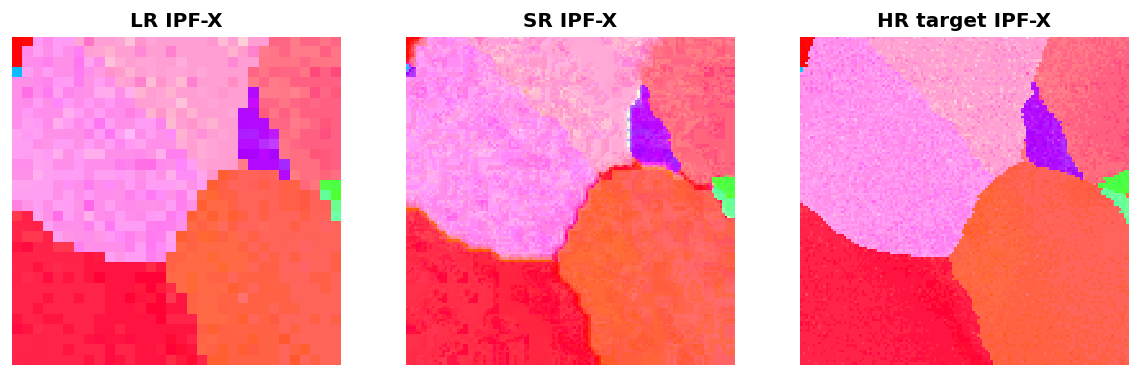

SR vs HR misorientation (deg): mean=2.284, median=1.154, max=60.891


In [29]:
with torch.no_grad():
    feat_lr = model.encode(_normalize_quaternions(lr_flat.to(model.device)))
    feat_hr_tgt = model.encode(_normalize_quaternions(hr_flat.to(model.device)))

feat_lr_b1 = feat_lr.view(1, -1, feat_lr.shape[-1]).detach()
feat_hr_tgt_b1 = feat_hr_tgt.view(1, -1, feat_hr_tgt.shape[-1]).detach()

with torch.enable_grad():
    sr_q_flat = model.forward_sr(lr_flat.to(model.device), lr_shape=lr_shape, normalize_input=True)

sr_q_hwc = sr_q_flat.detach().cpu().view(*hr_shape, 4)
sr_rgb = render_ipf_rgb(sr_q_hwc.numpy().astype(np.float32), sym_class, ref_dir=REF_DIR)
hr_rgb = render_ipf_rgb(hr_q_hwc.numpy().astype(np.float32), sym_class, ref_dir=REF_DIR)
lr_rgb = render_ipf_rgb(lr_q_hwc.numpy().astype(np.float32), sym_class, ref_dir=REF_DIR)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes,
    [lr_rgb, sr_rgb, hr_rgb],
    [f"LR IPF-{REF_DIR}", f"SR IPF-{REF_DIR}", f"HR target IPF-{REF_DIR}"],
):
    ax.imshow(img, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.show()

global_mis = quat_ang_err_deg(sr_q_hwc, hr_q_hwc, sym=sym_class)
print(
    f"SR vs HR misorientation (deg): mean={global_mis.mean().item():.3f}, "
    f"median={global_mis.median().item():.3f}, max={global_mis.max().item():.3f}"
)


## Manual RRCTP Trace

The cell below does **not** call the model only through `forward_sr`. Instead, it reproduces
the RRCTP logic step by step from the trained modules:

- parent-feature lift to HR tokens
- phase embedding
- query anchor
- candidate bank gates and scores
- expert-specific pooled contexts
- invariant router logits and top-k experts
- expert seed proposals and final mixed seed

This is the main trace object used by the rest of the notebook.


In [30]:
trace = trace_rrctp_substeps(model, feat_lr_b1, lr_shape)

with torch.no_grad():
    feat_seed_direct, _ = model._forward_sr_features(feat_lr_b1, lr_shape=lr_shape, return_aux=False)
seed_consistency = (trace["stages"]["seed_final"] - feat_seed_direct[0].detach().cpu()).abs().max().item()

print("Trace built.")
print("Seed consistency vs model._forward_sr_features max abs diff:", seed_consistency)
print("candidate_bank shape :", tuple(trace["candidate_bank"].shape))
print("alpha shape          :", tuple(trace["alpha"].shape))
print("contexts shape       :", tuple(trace["contexts"].shape))
print("router_logits shape  :", tuple(trace["router_logits"].shape))
print("seed_all shape       :", tuple(trace["seed_all"].shape))


Trace built.
Seed consistency vs model._forward_sr_features max abs diff: 5.960464477539063e-08
candidate_bank shape : (16384, 25, 14)
alpha shape          : (16384, 8, 25)
contexts shape       : (16384, 8, 14)
router_logits shape  : (16384, 8)
seed_all shape       : (16384, 8, 14)


## Global Maps: Where the HR Pixels Pull Evidence From

Before zooming into one HR pixel, it helps to look at three global indicators:

- **top-1 expert id**: which expert dominates at each HR location
- **non-parent mass**: how much of the top-1 expert attention lives away from the
  center candidate (the mapped parent LR pixel)
- **expected LR offset magnitude**: the center-of-mass shift of the top-1 expert
  candidate weights inside the `5x5` bank

The second and third maps answer the main interpretability question: they show that
the model is not restricted to the parent LR pixel, even though that parent feature is
the starting point for the query anchor.


Fraction of HR pixels with top-1 non-parent mass > 0.25: 1.0
Mean top-1 non-parent mass: 0.9773712158203125
Mean top-1 expected LR-offset magnitude: 1.0669236183166504


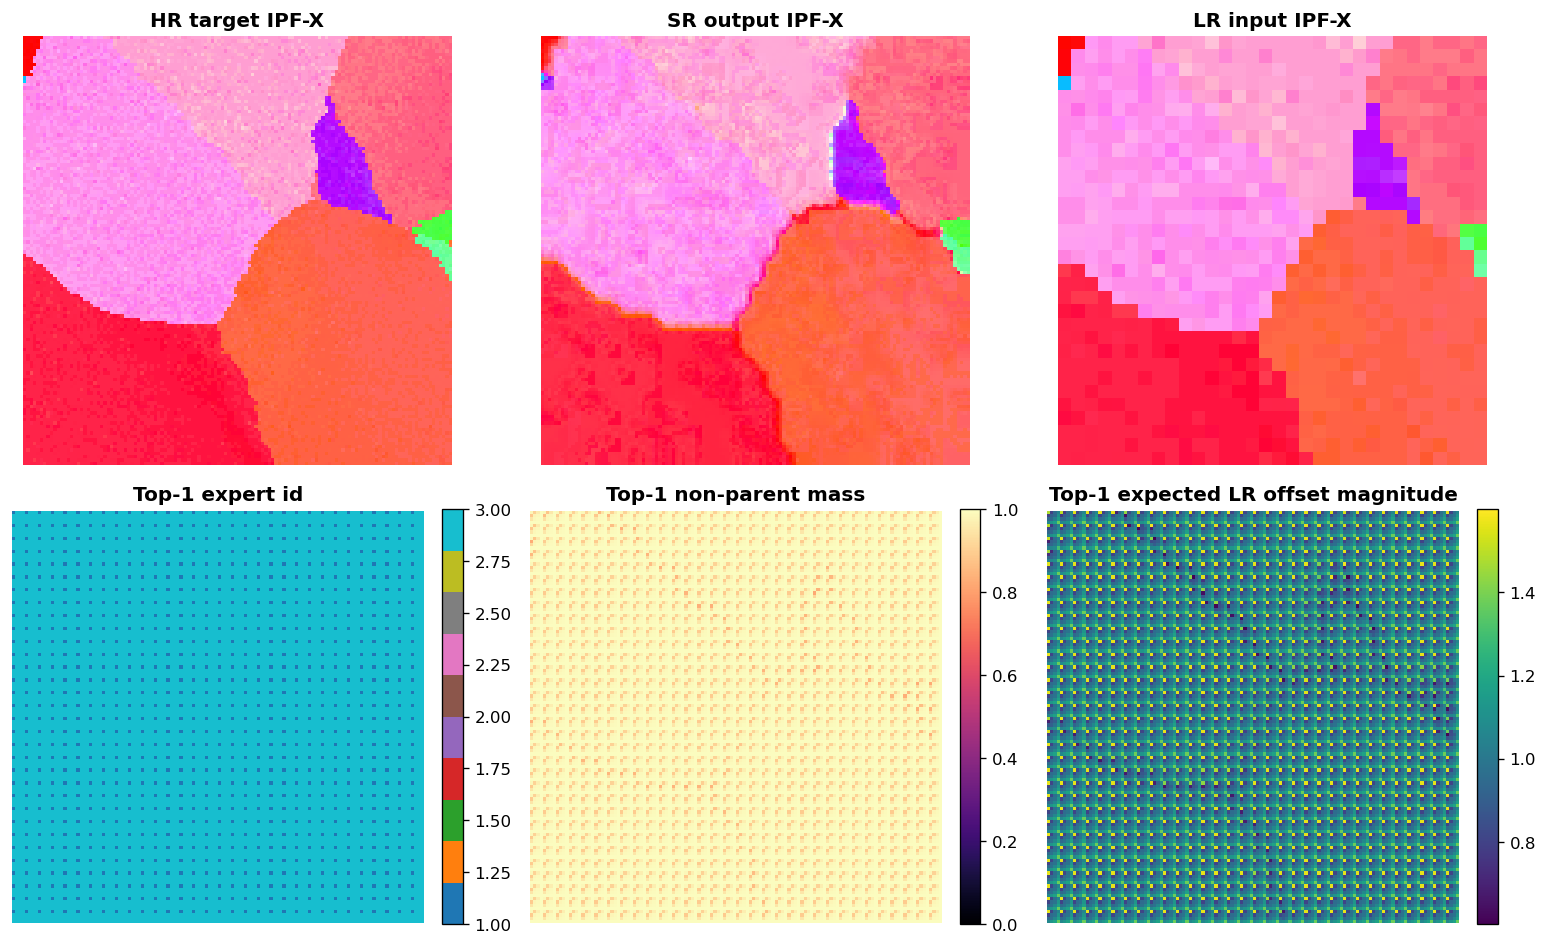

In [31]:
h_hr, w_hr = trace["h_hr"], trace["w_hr"]
top1_expert_map = trace["topk_idx"][:, 0].view(h_hr, w_hr).numpy()
top1_pi_map = trace["topk_pi"][:, 0].view(h_hr, w_hr).numpy()
non_parent_mass_map = trace["non_parent_mass_top1"].view(h_hr, w_hr).numpy()
shift_mag_map = trace["shift_mag_top1"].view(h_hr, w_hr).numpy()

print("Fraction of HR pixels with top-1 non-parent mass > 0.25:",
      float((non_parent_mass_map > 0.25).mean()))
print("Mean top-1 non-parent mass:", float(non_parent_mass_map.mean()))
print("Mean top-1 expected LR-offset magnitude:", float(shift_mag_map.mean()))

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes[0, 0].imshow(hr_rgb, interpolation="nearest")
axes[0, 0].set_title(f"HR target IPF-{REF_DIR}")
axes[0, 1].imshow(sr_rgb, interpolation="nearest")
axes[0, 1].set_title(f"SR output IPF-{REF_DIR}")
axes[0, 2].imshow(lr_rgb, interpolation="nearest")
axes[0, 2].set_title(f"LR input IPF-{REF_DIR}")
for ax in axes[0]:
    ax.axis("off")

im0 = axes[1, 0].imshow(top1_expert_map, cmap="tab10", interpolation="nearest")
axes[1, 0].set_title("Top-1 expert id")
axes[1, 0].axis("off")
plt.colorbar(im0, ax=axes[1, 0], fraction=0.046, pad=0.04)

im1 = axes[1, 1].imshow(non_parent_mass_map, cmap="magma", vmin=0.0, vmax=1.0, interpolation="nearest")
axes[1, 1].set_title("Top-1 non-parent mass")
axes[1, 1].axis("off")
plt.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04)

im2 = axes[1, 2].imshow(shift_mag_map, cmap="viridis", interpolation="nearest")
axes[1, 2].set_title("Top-1 expected LR offset magnitude")
axes[1, 2].axis("off")
plt.colorbar(im2, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Pick Four Adjacent Boundary Pixels to Explain

By default, the notebook now looks for a **boundary color anomaly**: an SR pixel on a
strong HR boundary whose SR IPF color does not match either of the two dominant HR grain
colors in its local neighborhood. This is the kind of “white seam / off-grain color”
artifact that is easy to see in the SR image but hard to explain without tracing the
RRCTP path. In the current notebook, `MANUAL_PROBE_YX` is already set to the seam pixel
from the provided figure, and the notebook then grows a connected **4-pixel boundary strip**
around that anchor so you can compare neighboring HR pixels along the same artifact.


In [32]:
anchor_y, anchor_x, anchor_flat, probe_info = choose_probe_pixel(
    trace,
    manual_yx=MANUAL_PROBE_YX,
    mode=AUTO_PROBE_MODE,
    sr_rgb=sr_rgb,
    hr_rgb=hr_rgb,
)
probe_pixels, probe_maps = build_adjacent_probe_pixels(
    (anchor_y, anchor_x),
    sr_rgb=sr_rgb,
    hr_rgb=hr_rgb,
    count=NUM_PROBE_PIXELS,
)

probe_rows = []
for probe_id, (probe_y, probe_x) in enumerate(probe_pixels):
    probe_flat = probe_y * w_hr + probe_x
    parent_y = int(trace["parent_y"][probe_flat].item())
    parent_x = int(trace["parent_x"][probe_flat].item())
    phase_id = int(trace["phase_idx"][probe_flat].item())
    topk_ids = trace["topk_idx"][probe_flat].tolist()
    topk_weights = [round(float(v), 4) for v in trace["topk_pi"][probe_flat].tolist()]
    probe_rows.append(
        {
            "probe_id": f"P{probe_id}",
            "is_anchor": bool(probe_id == 0),
            "hr_y": int(probe_y),
            "hr_x": int(probe_x),
            "flat": int(probe_flat),
            "parent_lr_y": int(parent_y),
            "parent_lr_x": int(parent_x),
            "phase_id": int(phase_id),
            "topk_experts": str(topk_ids),
            "topk_weights": str(topk_weights),
            "top1_non_parent_mass": float(trace["non_parent_mass_top1"][probe_flat].item()),
            "top1_expected_offset_y": float(trace["mean_offset_top1"][probe_flat, 0].item()),
            "top1_expected_offset_x": float(trace["mean_offset_top1"][probe_flat, 1].item()),
            "sr_hr_rgb_gap": float(probe_maps["rgb_gap"][probe_y, probe_x]),
            "hr_boundary_strength": float(probe_maps["hr_grad"][probe_y, probe_x]),
            "sr_boundary_strength": float(probe_maps["sr_grad"][probe_y, probe_x]),
        }
    )

probe_df = pd.DataFrame(probe_rows)
print("Anchor seam pixel:", (anchor_y, anchor_x))
if probe_info is not None:
    print("Boundary color anomaly score:", round(float(probe_info["score"]), 4))
    print("Distance from SR color to local grain colors:",
          round(float(probe_info["d_to_c1"]), 4),
          round(float(probe_info["d_to_c2"]), 4))
    print("Local HR grain-color separation:", round(float(probe_info["center_sep"]), 4))
    print("Estimated local grain colors (RGB):")
    print("  c1 =", np.round(probe_info["c1"], 4))
    print("  c2 =", np.round(probe_info["c2"], 4))
display(probe_df)


Anchor seam pixel: (50, 82)


,probe_id,is_anchor,hr_y,hr_x,flat,parent_lr_y,parent_lr_x,phase_id,topk_experts,topk_weights,top1_non_parent_mass,top1_expected_offset_y,top1_expected_offset_x,sr_hr_rgb_gap,hr_boundary_strength,sr_boundary_strength
0,P0,True,50,82,6482,12,20,10,"[3, 1]","[1.0, 0.0]",0.994331,0.735136,0.657457,0.560744,0.600935,0.480275
1,P1,False,50,81,6481,12,20,9,"[3, 1]","[0.9999, 0.0001]",0.987273,0.780864,0.476991,0.718455,0.600488,0.640850
2,P2,False,51,80,6608,12,20,12,"[3, 1]","[1.0, 0.0]",0.996797,1.044309,0.021120,0.796491,0.680986,0.544536
3,P3,False,52,79,6735,13,19,3,"[3, 0]","[1.0, 0.0]",0.996912,0.029219,1.031911,0.891806,0.674772,0.422375


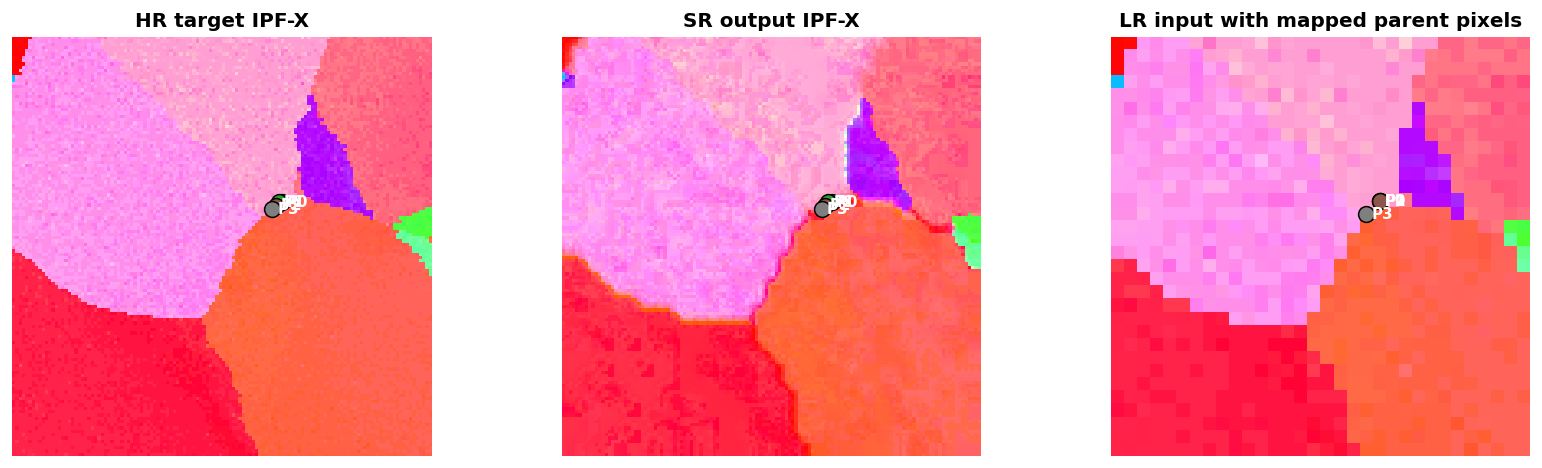

In [33]:
probe_colors = plt.cm.tab10(np.linspace(0.0, 1.0, len(probe_df), endpoint=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, img, title in zip(
    axes,
    [hr_rgb, sr_rgb, lr_rgb],
    [f"HR target IPF-{REF_DIR}", f"SR output IPF-{REF_DIR}", f"LR input IPF-{REF_DIR}"],
):
    ax.imshow(img, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

for row_idx, row in probe_df.iterrows():
    color = probe_colors[row_idx]
    hr_y = int(row["hr_y"])
    hr_x = int(row["hr_x"])
    parent_y = int(row["parent_lr_y"])
    parent_x = int(row["parent_lr_x"])

    for ax in axes[:2]:
        ax.scatter([hr_x], [hr_y], s=90, c=[color], edgecolors="black", linewidths=0.9)
        ax.text(hr_x + 1.5, hr_y + 1.5, row["probe_id"], color="white", fontsize=9, weight="bold")

    axes[2].scatter([parent_x], [parent_y], s=90, c=[color], edgecolors="black", linewidths=0.9)
    axes[2].text(parent_x + 0.4, parent_y + 0.4, row["probe_id"], color="white", fontsize=9, weight="bold")

axes[2].set_title("LR input with mapped parent pixels")

plt.tight_layout()
plt.show()


## Candidate Banks for the 4-Pixel Boundary Strip

The tables below are where the semiglobal selection logic becomes concrete.

For each probe pixel `P0`-`P3`, each row is one candidate LR pixel from that pixel's `5x5`
bank. The tables report:

- the absolute LR coordinates
- whether the candidate is the mapped parent pixel
- the total gate value
- the top-1 and top-2 expert attention weights on that candidate
- the symmetry-aware misorientation between that LR candidate quaternion and the HR target quaternion

If the largest weights sit on non-parent candidates, that is direct evidence that RRCTP is
pulling relevant information from neighboring LR locations rather than blindly copying the parent token.


#### P0 at HR (50, 82)

,probe_id,bank_idx,lr_y,lr_x,is_parent,gate,alpha_top1,alpha_top2,score_top1,score_top2,target_mis_deg
0,P0,18,13,21,False,0.325315,0.375429,0.226345,6.527164,2.943760,43.478771
1,P0,17,13,20,False,0.351878,0.339138,0.071759,6.347013,1.716527,43.613983
2,P0,13,12,21,False,0.504382,0.262667,0.113904,5.731444,1.818519,1.121159
3,P0,12,12,20,True,0.107930,0.005669,0.005440,3.437338,0.318713,0.000000
4,P0,22,14,20,False,0.155775,0.004914,0.027152,2.927665,1.559554,43.431980
5,P0,14,12,22,False,0.191658,0.004759,0.058784,2.688260,2.124651,15.355546
6,P0,23,14,21,False,0.192779,0.003817,0.122925,2.461740,2.856524,43.271229
7,P0,19,13,22,False,0.170340,0.002819,0.144644,2.282450,3.142980,43.271229
8,P0,8,11,21,False,0.257777,0.000231,0.005074,-0.634547,-0.621516,0.000000
9,P0,16,13,19,False,0.261658,0.000191,0.002921,-0.837097,-1.188709,0.999354


#### P1 at HR (50, 81)

,probe_id,bank_idx,lr_y,lr_x,is_parent,gate,alpha_top1,alpha_top2,score_top1,score_top2,target_mis_deg
0,P1,17,13,20,False,0.351878,0.503603,0.112061,7.696587,1.618801,43.613983
1,P1,18,13,21,False,0.325315,0.249202,0.221814,7.071552,2.380085,43.478771
2,P1,13,12,21,False,0.504382,0.216015,0.141991,6.490096,1.495470,1.121159
3,P1,12,12,20,True,0.107930,0.012727,0.011265,5.200316,0.503228,0.000000
4,P1,22,14,20,False,0.155775,0.008263,0.037078,4.401461,1.327646,43.431980
5,P1,23,14,21,False,0.192779,0.004155,0.117297,3.500828,2.266201,43.271229
6,P1,14,12,22,False,0.191658,0.002520,0.052112,3.006634,1.460717,15.355546
7,P1,19,13,22,False,0.170340,0.001653,0.109857,2.702829,2.324423,43.271229
8,P1,16,13,19,False,0.261658,0.000971,0.008064,1.741132,-0.716562,0.999354
9,P1,21,14,19,False,0.133529,0.000374,0.005327,1.461075,-0.458506,43.559177


#### P2 at HR (51, 80)

,probe_id,bank_idx,lr_y,lr_x,is_parent,gate,alpha_top1,alpha_top2,score_top1,score_top2,target_mis_deg
0,P2,17,13,20,False,0.351878,0.880917,0.115708,4.948816,2.286665,43.816998
1,P2,18,13,21,False,0.325315,0.040210,0.186400,1.940452,2.841986,43.657906
2,P2,22,14,20,False,0.155775,0.039516,0.081992,2.659442,2.757092,43.613998
3,P2,16,13,19,False,0.261658,0.015930,0.009338,1.232325,0.065976,1.413858
4,P2,21,14,19,False,0.133529,0.011516,0.012475,1.580511,1.028252,43.765144
5,P2,13,12,21,False,0.504382,0.005956,0.043616,-0.407716,0.950978,1.414412
6,P2,12,12,20,True,0.107930,0.003203,0.003879,0.513838,0.073009,1.000137
7,P2,23,14,21,False,0.192779,0.002504,0.212671,-0.312679,3.497084,43.431961
8,P2,11,12,19,False,0.359096,0.000105,0.001513,-4.108243,-2.070840,1.000137
9,P2,20,14,18,False,0.141814,0.000054,0.000915,-3.839887,-1.644152,59.282463


#### P3 at HR (52, 79)

,probe_id,bank_idx,lr_y,lr_x,is_parent,gate,alpha_top1,alpha_top2,score_top1,score_top2,target_mis_deg
0,P3,13,13,20,False,0.359110,0.884518,0.079481,6.329457,0.130813,43.613983
1,P3,18,14,20,False,0.328858,0.043758,0.088668,3.411089,0.328198,43.431980
2,P3,14,13,21,False,0.145098,0.033003,0.033300,3.947238,0.167086,43.478771
3,P3,8,12,20,False,0.257712,0.016486,0.040464,2.678702,-0.212493,0.000000
4,P3,9,12,21,False,0.182482,0.008493,0.031337,2.360676,-0.122913,1.121159
5,P3,17,14,19,False,0.355704,0.008389,0.089549,1.680856,0.259619,43.559177
6,P3,12,13,19,True,0.107930,0.003088,0.020700,1.874070,-0.012413,0.999354
7,P3,19,14,21,False,0.171777,0.002031,0.047489,0.990137,0.353223,43.271229
8,P3,7,12,19,False,0.375141,0.000113,0.050025,-2.677769,-0.375847,0.000000
9,P3,23,15,20,False,0.193715,0.000051,0.060122,-2.810467,0.468919,43.404449


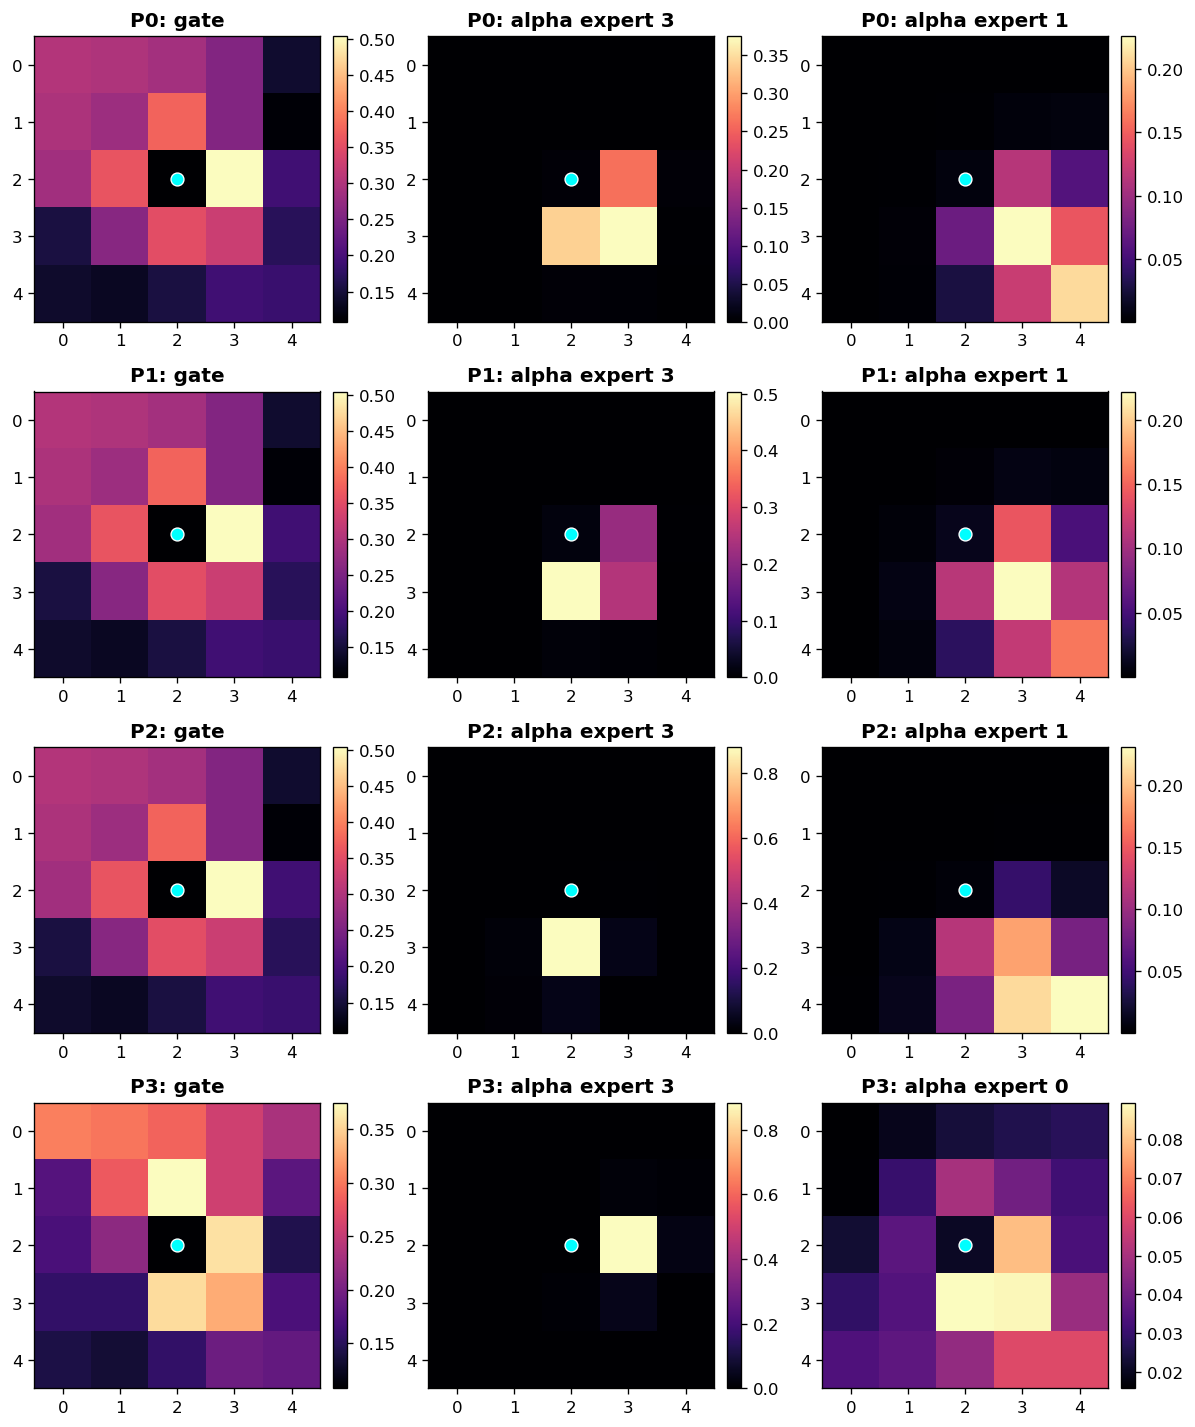

In [34]:
parent_center = trace["parent_center"]
probe_candidate_tables = {}
probe_heatmaps = []

for _, row in probe_df.iterrows():
    probe_id = row["probe_id"]
    probe_y = int(row["hr_y"])
    probe_x = int(row["hr_x"])
    probe_flat = int(row["flat"])
    hr_target_q = hr_q_hwc[probe_y, probe_x]

    cand_y = trace["cand_y"][probe_flat].numpy()
    cand_x = trace["cand_x"][probe_flat].numpy()
    top1_expert = int(trace["topk_idx"][probe_flat, 0].item())
    top2_expert = int(trace["topk_idx"][probe_flat, 1].item()) if trace["topk_idx"].shape[1] > 1 else top1_expert

    alpha_top1 = trace["alpha"][probe_flat, top1_expert].numpy()
    alpha_top2 = trace["alpha"][probe_flat, top2_expert].numpy()
    gate_probe = trace["gate_total"][probe_flat].numpy()
    score_top1 = trace["candidate_score"][probe_flat, top1_expert].numpy()
    score_top2 = trace["candidate_score"][probe_flat, top2_expert].numpy()

    candidate_rows = []
    for m in range(trace["candidate_bank"].shape[1]):
        yy = int(cand_y[m])
        xx = int(cand_x[m])
        lr_candidate_q = lr_q_hwc[yy, xx]
        candidate_rows.append(
            {
                "probe_id": probe_id,
                "bank_idx": m,
                "lr_y": yy,
                "lr_x": xx,
                "is_parent": bool(m == parent_center),
                "gate": float(gate_probe[m]),
                "alpha_top1": float(alpha_top1[m]),
                "alpha_top2": float(alpha_top2[m]),
                "score_top1": float(score_top1[m]),
                "score_top2": float(score_top2[m]),
                "target_mis_deg": pair_misorientation_deg(lr_candidate_q, hr_target_q, sym_class),
            }
        )

    candidate_df = pd.DataFrame(candidate_rows).sort_values(
        ["alpha_top1", "alpha_top2", "gate"],
        ascending=False,
    ).reset_index(drop=True)
    probe_candidate_tables[probe_id] = candidate_df

    display(Markdown(f"#### {probe_id} at HR ({probe_y}, {probe_x})"))
    display(candidate_df.head(TOP_CANDIDATES_TO_SHOW))

    probe_heatmaps.append(
        (
            probe_id,
            gate_probe.reshape(5, 5),
            alpha_top1.reshape(5, 5),
            alpha_top2.reshape(5, 5),
            top1_expert,
            top2_expert,
        )
    )

fig, axes = plt.subplots(len(probe_heatmaps), 3, figsize=(10, 3 * len(probe_heatmaps)))
if len(probe_heatmaps) == 1:
    axes = axes[None, :]

for row_idx, (probe_id, gate_grid, alpha_top1_grid, alpha_top2_grid, top1_expert, top2_expert) in enumerate(probe_heatmaps):
    for col_idx, (arr, title) in enumerate(
        [
            (gate_grid, "gate"),
            (alpha_top1_grid, f"alpha expert {top1_expert}"),
            (alpha_top2_grid, f"alpha expert {top2_expert}"),
        ]
    ):
        ax = axes[row_idx, col_idx]
        im = ax.imshow(arr, cmap="magma", interpolation="nearest")
        ax.set_title(f"{probe_id}: {title}")
        ax.set_xticks(range(5))
        ax.set_yticks(range(5))
        ax.scatter([2], [2], s=60, c="cyan", edgecolors="white", linewidths=0.8)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Stage-by-Stage Decoder Viability for the 4-Pixel Boundary Strip

The current checkpoint was trained in the **full FCC feature space** (`2e ⊕ 4e`), but the
local-iso active subspace is the FCC `a1 = 4e` block. For each stage listed below, we therefore
look at two decodes:

- **decode(full)**: send the full feature vector through the trained full decoder
- **decode(a1 slice)**: take only the trailing FCC `a1` block and decode that with an `a1` decoder

This lets us see both:

- whether the stage is already decoder-viable in the trained feature space
- how much of that decoder-viable content is already concentrated in the `a1` block


,probe_id,hr_y,hr_x,stage,full_norm,a1_norm,a1_ratio,mis_full_deg,mis_a1_deg
0,P0,50,82,parent_feat,0.387298,0.387298,1.0,2.966379,2.966643
1,P0,50,82,query_anchor,0.193680,0.193680,1.0,2.966379,2.966379
2,P0,50,82,bank_sum,0.254553,0.254553,1.0,6.985901,6.986013
3,P0,50,82,ctx_top1,0.293964,0.293964,1.0,36.732880,36.732857
4,P0,50,82,ctx_mix_topk,0.293964,0.293964,1.0,36.732880,36.732857
5,P0,50,82,seed_top1,0.215614,0.215614,1.0,17.558477,17.558207
6,P0,50,82,seed_final,0.215614,0.215614,1.0,17.558521,17.558252
7,P1,50,81,parent_feat,0.387298,0.387298,1.0,2.966379,2.966643
8,P1,50,81,query_anchor,0.193796,0.193796,1.0,2.966643,2.966643
9,P1,50,81,bank_sum,0.254554,0.254553,1.0,6.985901,6.986013


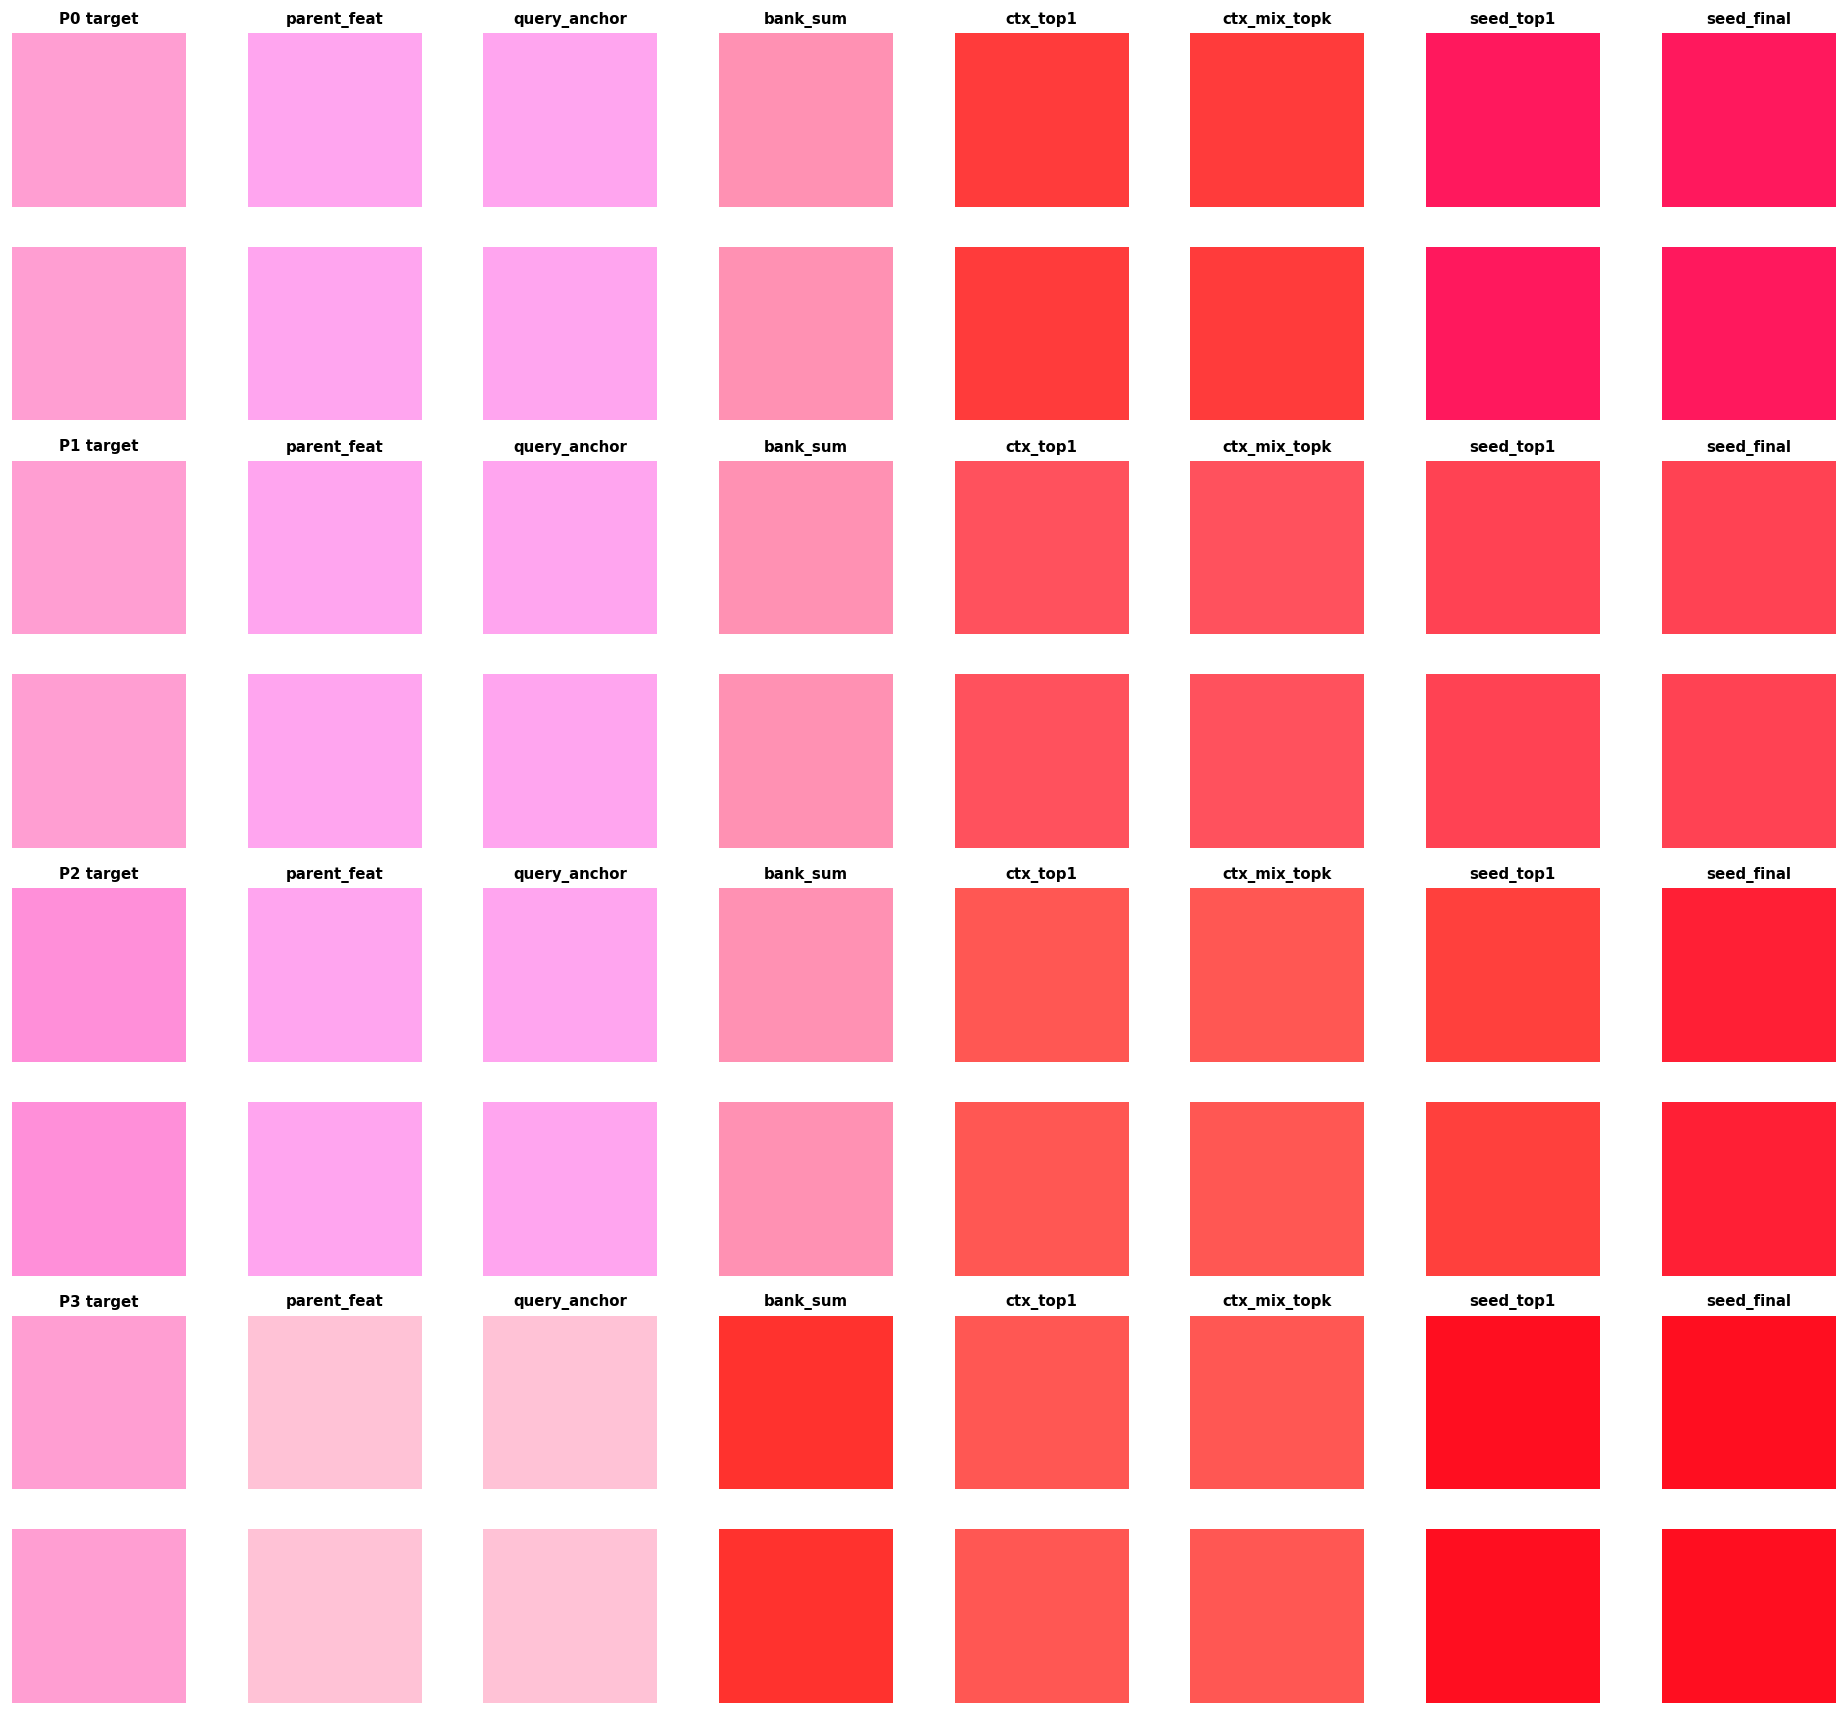

In [35]:
stage_order = [
    "parent_feat",
    "query_anchor",
    "bank_sum",
    "ctx_top1",
    "ctx_mix_topk",
    "seed_top1",
    "seed_final",
]

stage_rows = []
probe_stage_swatches = []

for _, row in probe_df.iterrows():
    probe_id = row["probe_id"]
    probe_y = int(row["hr_y"])
    probe_x = int(row["hr_x"])
    probe_flat = int(row["flat"])
    hr_target_q = hr_q_hwc[probe_y, probe_x]
    target_swatch = quat_rgb_swatch(hr_target_q, sym_class, ref_dir=REF_DIR)

    full_swatches = []
    a1_swatches = []
    for stage_name in stage_order:
        stage_feat = trace["stages"][stage_name][probe_flat]
        feat_full = stage_feat.view(1, -1)
        feat_a1 = stage_feat[a1_slice].view(1, -1)

        q_full = decode_full_features(model, feat_full)[0]
        q_a1 = decode_a1_features(model, decoder_a1, feat_a1)[0]

        full_norm = float(stage_feat.norm().item())
        a1_norm = float(stage_feat[a1_slice].norm().item())
        a1_ratio = a1_norm / max(full_norm, 1e-8)

        mis_full = pair_misorientation_deg(q_full, hr_target_q, sym_class)
        mis_a1 = pair_misorientation_deg(q_a1, hr_target_q, sym_class)

        stage_rows.append(
            {
                "probe_id": probe_id,
                "hr_y": int(probe_y),
                "hr_x": int(probe_x),
                "stage": stage_name,
                "full_norm": full_norm,
                "a1_norm": a1_norm,
                "a1_ratio": a1_ratio,
                "mis_full_deg": mis_full,
                "mis_a1_deg": mis_a1,
            }
        )
        full_swatches.append(quat_rgb_swatch(q_full, sym_class, ref_dir=REF_DIR))
        a1_swatches.append(quat_rgb_swatch(q_a1, sym_class, ref_dir=REF_DIR))

    probe_stage_swatches.append(
        {
            "probe_id": probe_id,
            "target_swatch": target_swatch,
            "full_swatches": full_swatches,
            "a1_swatches": a1_swatches,
        }
    )

stage_df = pd.DataFrame(stage_rows)
display(stage_df)

fig, axes = plt.subplots(
    2 * len(probe_stage_swatches),
    len(stage_order) + 1,
    figsize=(2.0 * (len(stage_order) + 1), 1.8 * (2 * len(probe_stage_swatches))),
)
if axes.ndim == 1:
    axes = axes[None, :]
for ax in axes.reshape(-1):
    ax.axis("off")

for i, item in enumerate(probe_stage_swatches):
    probe_id = item["probe_id"]
    target_swatch = item["target_swatch"]
    full_swatches = item["full_swatches"]
    a1_swatches = item["a1_swatches"]
    row_full = 2 * i
    row_a1 = 2 * i + 1

    axes[row_full, 0].imshow(np.ones((20, 20, 3), dtype=np.float32) * target_swatch[None, None, :])
    axes[row_a1, 0].imshow(np.ones((20, 20, 3), dtype=np.float32) * target_swatch[None, None, :])
    axes[row_full, 0].set_title(f"{probe_id} target", fontsize=9)
    axes[row_full, 0].set_ylabel(f"{probe_id}\nfull", rotation=0, labelpad=26, va="center")
    axes[row_a1, 0].set_ylabel(f"{probe_id}\na1", rotation=0, labelpad=26, va="center")

    for j, stage_name in enumerate(stage_order, start=1):
        axes[row_full, j].imshow(np.ones((20, 20, 3), dtype=np.float32) * full_swatches[j - 1][None, None, :])
        axes[row_a1, j].imshow(np.ones((20, 20, 3), dtype=np.float32) * a1_swatches[j - 1][None, None, :])
        axes[row_full, j].set_title(stage_name, fontsize=9)

plt.tight_layout()
plt.show()


## A1 Persistence Maps Across the Whole HR Grid

For the global picture, the next cell computes

$$
\text{a1 ratio}(u) = \frac{\|f_u^{a1}\|}{\|f_u^{full}\|}
$$

for a few representative stage maps. This is not a training loss; it is just a diagnostic
of how much of the stage energy is already concentrated in the active FCC `a1` block.


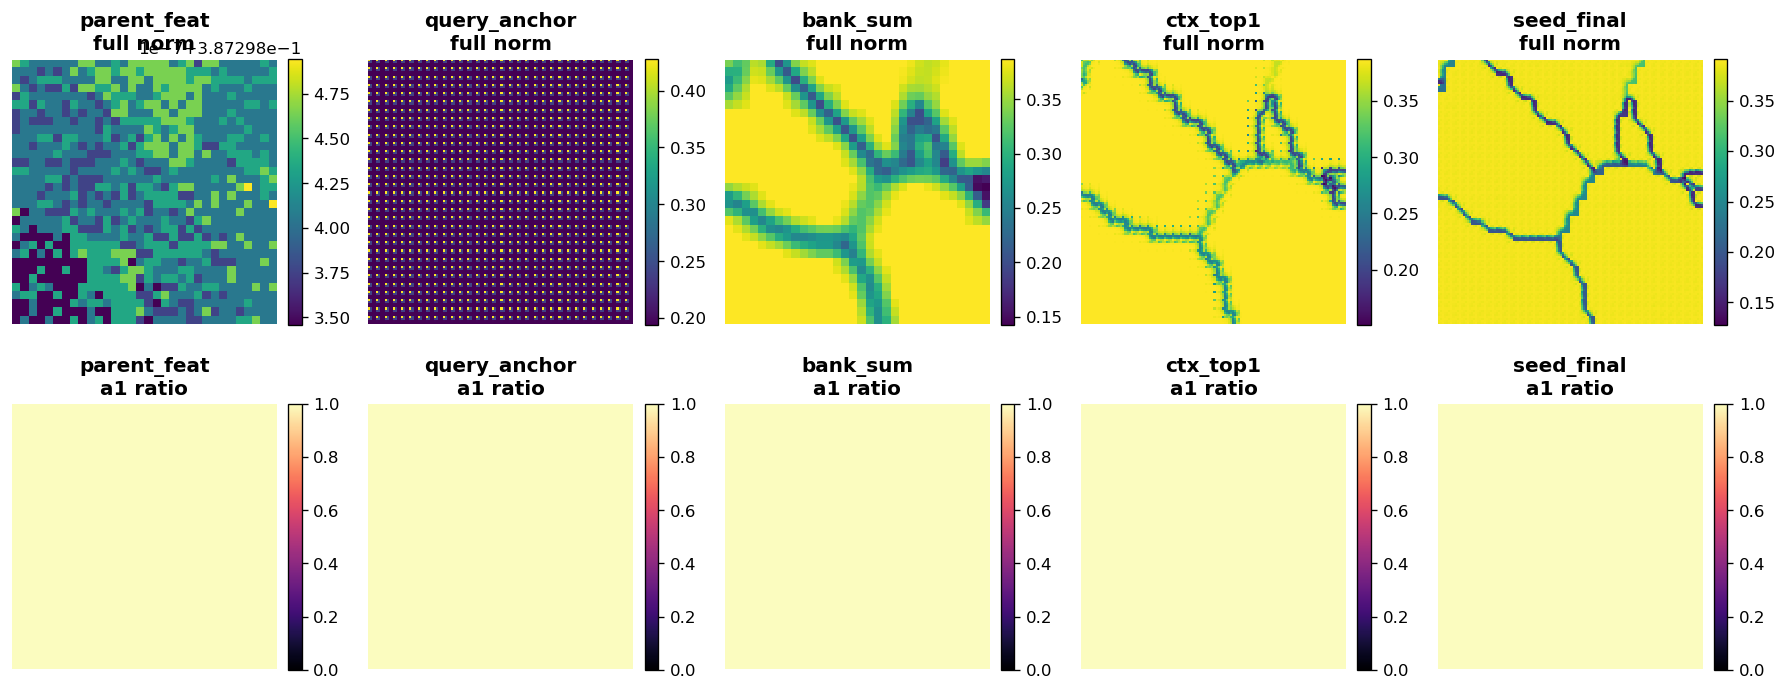

In [36]:
stage_map_names = ["parent_feat", "query_anchor", "bank_sum", "ctx_top1", "seed_final"]
fig, axes = plt.subplots(2, len(stage_map_names), figsize=(3.0 * len(stage_map_names), 6))

for j, stage_name in enumerate(stage_map_names):
    stage_feat = trace["stages"][stage_name]
    full_norm, a1_norm, a1_ratio = stage_a1_stats(stage_feat, a1_slice)
    a1_ratio_map = a1_ratio.view(h_hr, w_hr).numpy()
    full_norm_map = full_norm.view(h_hr, w_hr).numpy()

    im0 = axes[0, j].imshow(full_norm_map, cmap="viridis", interpolation="nearest")
    axes[0, j].set_title(f"{stage_name}\nfull norm")
    axes[0, j].axis("off")
    plt.colorbar(im0, ax=axes[0, j], fraction=0.046, pad=0.04)

    im1 = axes[1, j].imshow(a1_ratio_map, cmap="magma", vmin=0.0, vmax=1.0, interpolation="nearest")
    axes[1, j].set_title(f"{stage_name}\na1 ratio")
    axes[1, j].axis("off")
    plt.colorbar(im1, ax=axes[1, j], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## What This Notebook Lets You Check

At this point you can answer the key interpretability questions directly from the traced tensors:

- **Does the model only use the mapped parent LR pixel?**  
  No. The `top-1 non-parent mass` map and the per-pixel candidate table show how much of the
  selected expert attention is allocated away from the center candidate.

- **What is the parent LR feature still doing?**  
  It provides the starting local anchor that becomes `q_u^0`, but the final seed can be dominated
  by semiglobal evidence pooled from other candidates inside the `5x5` bank.

- **Which stages are already decoder-viable across the boundary strip?**  
  The stage table and swatches show exactly what quaternion each intermediate feature would decode to,
  for all four neighboring boundary pixels, both in the full trained feature space and in the FCC `a1` slice.

- **How much `a1` content persists?**  
  The `a1 ratio` maps show whether a stage is mostly carrying decoder-relevant active content, or whether
  substantial energy is still living outside the `a1` block.

Useful things to try next:

- change `MANUAL_PROBE_YX` and re-run the probe section
- switch `AUTO_PROBE_MODE` between `"boundary_color_anomaly"`, `"largest_non_parent_mass"`, and `"largest_shift"`
- change `REF_DIR` from `"X"` to `"Y"` or `"Z"` for a different IPF view
- compare `seed_final` against a parent-only baseline by decoding `parent_feat` and `seed_final` side by side
